In [28]:
%reset -f

In [1]:
from linearmodels.panel           import PooledOLS, RandomEffects, compare
from linearmodels                 import PanelOLS
from statsmodels.stats.diagnostic import het_white, het_breuschpagan
from statsmodels.stats.stattools  import durbin_watson
from scipy                        import stats

import numpy.linalg      as la
import matplotlib.pyplot as plt
import numpy             as np
import pandas            as pd
import statsmodels.api   as sm

In [2]:
data = pd.read_csv("/home/michael/Projects/regression_analysis/data/Co2.csv")
# get data from CP study

In [3]:
data.columns

Index(['iso_code', 'country', 'OECD', 'EU', 'year', 'co2', 'co2_growth_prct',
       'co2_per_capita', 'share_global_co2', 'cumulative_co2',
       'share_global_cumulative_co2', 'co2_per_gdp', 'population', 'gdp',
       'Feed - in - Tariff', '% Share of Energy consumption from renewables',
       'Carbon_price_DV',
       'Effective Carbon Price (Sum of {carbon price rate * proportion of countries CO2 covered})'],
      dtype='str')

In [4]:
data.year

0       1990
1       1991
2       1992
3       1993
4       1994
        ... 
4693    2014
4694    2015
4695    2016
4696    2017
4697    2018
Name: year, Length: 4698, dtype: int64

In [5]:
data['year'].dtypes

dtype('int64')

In [6]:
data['iso_code'].dtypes

<StringDtype(storage='python', na_value=nan)>

# transform them into index (categorical variables)

In [7]:
year = pd.Categorical(data.year)
iso_code  = pd.Categorical(data.iso_code)

# set panel id as "id" and "year" befpre checking the table

In [8]:
data = data.set_index(['iso_code', 'year'])

In [9]:
data['year'] = year
data['iso_code']  = iso_code

In [10]:
data['year'].dtypes

CategoricalDtype(categories=[1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999,
                  2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
                  2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018],
, ordered=False, categories_dtype=int64)

In [11]:
data['iso_code'].dtypes

CategoricalDtype(categories=['AFG', 'AGO', 'ALB', 'ARE', 'ARG', 'ARM', 'AUS', 'AUT',
                  'AZE', 'BDI',
                  ...
                  'UKR', 'URY', 'USA', 'UZB', 'VEN', 'VNM', 'YEM', 'ZAF',
                  'ZMB', 'ZWE'],
, ordered=False, categories_dtype=str)

# Now we can check the table

In [12]:
data.describe

<bound method NDFrame.describe of                    country  OECD  EU     co2  co2_growth_prct  co2_per_capita  \
iso_code year                                                                   
AFG      1990  Afghanistan     0   0   2.603            -5.85           0.210   
         1991  Afghanistan     0   0   2.427            -6.76           0.182   
         1992  Afghanistan     0   0   1.379           -43.17           0.095   
         1993  Afghanistan     0   0   1.333            -3.36           0.084   
         1994  Afghanistan     0   0   1.282            -3.86           0.075   
...                    ...   ...  ..     ...              ...             ...   
ZWE      2014     Zimbabwe     0   0  11.906             0.59           0.876   
         2015     Zimbabwe     0   0  12.226             2.69           0.885   
         2016     Zimbabwe     0   0  10.738           -12.17           0.765   
         2017     Zimbabwe     0   0   9.582           -10.77           0.6

In [13]:
data.head()

country  OECD  EU    co2  co2_growth_prct  co2_per_capita  \
iso_code year                                                                  
AFG      1990  Afghanistan     0   0  2.603            -5.85           0.210   
         1991  Afghanistan     0   0  2.427            -6.76           0.182   
         1992  Afghanistan     0   0  1.379           -43.17           0.095   
         1993  Afghanistan     0   0  1.333            -3.36           0.084   
         1994  Afghanistan     0   0  1.282            -3.86           0.075   

               share_global_co2  cumulative_co2  share_global_cumulative_co2  \
iso_code year                                                                  
AFG      1990              0.01          59.182                         0.01   
         1991              0.01          61.610                         0.01   
         1992              0.01          62.989                         0.01   
         1993              0.01          64.322                         0.01   
         1994              0.01          65.604                         0.01   

               co2_per_gdp  population           gdp  Feed - in - Tariff  \
iso_code year                                                              
AFG      1990        0.199    12412311  1.306598e+10                 0.0   
         1991        0.202    13299016  1.204736e+10                 0.0   
         1992        0.109    14485543  1.267754e+10                 0.0   
         1993        0.136    15816601  9.834581e+09                 0.0   
         1994        0.162    17075728  7.919857e+09                 0.0   

               % Share of Energy consumption from renewables  Carbon_price_DV  \
iso_code year                                                                   
AFG      1990                                            0.0                0   
         1991                                            0.0                0   
         1992                                            0.0                0   
         1993                                            0.0                0   
         1994                                            0.0                0   

               Effective Carbon Price (Sum of {carbon price rate * proportion of countries CO2 covered})  \
iso_code year                                                                                              
AFG      1990                                                0.0                                           
         1991                                                0.0                                           
         1992                                                0.0                                           
         1993                                                0.0                                           
         1994                                                0.0                                           

               year iso_code  
iso_code year                 
AFG      1990  1990      AFG  
         1991  1991      AFG  
         1992  1992      AFG  
         1993  1993      AFG  
         1994  1994      AFG

In [14]:
data.tail()

country  OECD  EU     co2  co2_growth_prct  co2_per_capita  \
iso_code year                                                                
ZWE      2014  Zimbabwe     0   0  11.906             0.59           0.876   
         2015  Zimbabwe     0   0  12.226             2.69           0.885   
         2016  Zimbabwe     0   0  10.738           -12.17           0.765   
         2017  Zimbabwe     0   0   9.582           -10.77           0.673   
         2018  Zimbabwe     0   0  11.854            23.72           0.821   

               share_global_co2  cumulative_co2  share_global_cumulative_co2  \
iso_code year                                                                  
ZWE      2014              0.03         713.504                         0.05   
         2015              0.03         725.729                         0.05   
         2016              0.03         736.467                         0.05   
         2017              0.03         746.049                         0.05   
         2018              0.03         757.903                         0.05   

               co2_per_gdp  population           gdp  Feed - in - Tariff  \
iso_code year                                                              
ZWE      2014        0.561    13586710  2.122250e+10                 0.0   
         2015        0.581    13814642  2.102746e+10                 0.0   
         2016        0.512    14030338  2.096179e+10                 0.0   
         2017        0.437    14236599  2.194784e+10                 0.0   
         2018        0.522    14438812  2.271535e+10                 0.0   

               % Share of Energy consumption from renewables  Carbon_price_DV  \
iso_code year                                                                   
ZWE      2014                                            0.0                0   
         2015                                            0.0                0   
         2016                                            0.0                0   
         2017                                            0.0                0   
         2018                                            0.0                0   

               Effective Carbon Price (Sum of {carbon price rate * proportion of countries CO2 covered})  \
iso_code year                                                                                              
ZWE      2014                                                0.0                                           
         2015                                                0.0                                           
         2016                                                0.0                                           
         2017                                                0.0                                           
         2018                                                0.0                                           

               year iso_code  
iso_code year                 
ZWE      2014  2014      ZWE  
         2015  2015      ZWE  
         2016  2016      ZWE  
         2017  2017      ZWE  
         2018  2018      ZWE

# this is extremely important in database management (we can extract subtable exactly based on the panel id now)

---

# Now, let's do Pooled OLS

In [15]:
data.columns

Index(['country', 'OECD', 'EU', 'co2', 'co2_growth_prct', 'co2_per_capita',
       'share_global_co2', 'cumulative_co2', 'share_global_cumulative_co2',
       'co2_per_gdp', 'population', 'gdp', 'Feed - in - Tariff',
       '% Share of Energy consumption from renewables', 'Carbon_price_DV',
       'Effective Carbon Price (Sum of {carbon price rate * proportion of countries CO2 covered})',
       'year', 'iso_code'],
      dtype='str')

In [19]:
data[exog_vars]

population           gdp  Carbon_price_DV
iso_code year                                           
AFG      1990    12412311  1.306598e+10                0
         1991    13299016  1.204736e+10                0
         1992    14485543  1.267754e+10                0
         1993    15816601  9.834581e+09                0
         1994    17075728  7.919857e+09                0
...                   ...           ...              ...
ZWE      2014    13586710  2.122250e+10                0
         2015    13814642  2.102746e+10                0
         2016    14030338  2.096179e+10                0
         2017    14236599  2.194784e+10                0
         2018    14438812  2.271535e+10                0

[4698 rows x 3 columns]

In [17]:
data.co2_per_capita

iso_code  year
AFG       1990    0.210
          1991    0.182
          1992    0.095
          1993    0.084
          1994    0.075
                  ...  
ZWE       2014    0.876
          2015    0.885
          2016    0.765
          2017    0.673
          2018    0.821
Name: co2_per_capita, Length: 4698, dtype: float64

In [22]:
exog_vars = ['population', 'gdp', 'Carbon_price_DV']
exog = sm.add_constant(data[exog_vars])
mod_ols = PooledOLS(data.co2, exog, check_rank = False)
pooled_res = mod_ols.fit()
print(pooled_res)    

                          PooledOLS Estimation Summary                          
Dep. Variable:                    co2   R-squared:                        0.8990
Estimator:                  PooledOLS   R-squared (Between):              0.9249
No. Observations:                4698   R-squared (Within):               0.6902
Date:                Tue, Jun 16 2026   R-squared (Overall):              0.8990
Time:                        19:43:41   Log-likelihood                -3.212e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                   1.392e+04
Entities:                         162   P-value                           0.0000
Avg Obs:                       29.000   Distribution:                  F(3,4694)
Min Obs:                       29.000                                           
Max Obs:                       29.000   F-statistic (robust):          1.351e+04
                            

# now let's run OLS with robust se

In [25]:
mod_ols_robust = PooledOLS(data.co2, exog, check_rank = False)
pooled_robust_res = mod_ols_robust.fit(cov_type='robust')
print(pooled_robust_res)    

                          PooledOLS Estimation Summary                          
Dep. Variable:                    co2   R-squared:                        0.8990
Estimator:                  PooledOLS   R-squared (Between):              0.9249
No. Observations:                4698   R-squared (Within):               0.6902
Date:                Tue, Jun 16 2026   R-squared (Overall):              0.8990
Time:                        19:44:11   Log-likelihood                -3.212e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                   1.392e+04
Entities:                         162   P-value                           0.0000
Avg Obs:                       29.000   Distribution:                  F(3,4694)
Min Obs:                       29.000                                           
Max Obs:                       29.000   F-statistic (robust):             326.21
                            

# now let's compare two results

In [20]:
print(compare({"unadjusted se": pooled_res, "robust se": pooled_robust_res}))

                Model Comparison               
                      unadjusted se   robust se
-----------------------------------------------
Dep. Variable                 lfare       lfare
Estimator                 PooledOLS   PooledOLS
No. Observations               4596        4596
Cov. Est.                Unadjusted      Robust
R-squared                    0.4062      0.4062
R-Squared (Within)           0.1246      0.1246
R-Squared (Between)          0.4215      0.4215
R-Squared (Overall)          0.4062      0.4062
F-statistic                  523.18      523.18
P-value (F-stat)             0.0000      0.0000
=====================  ============ ===========
const                        6.2093      6.2093
                           (14.762)    (13.179)
y98                          0.0211      0.0211
                           (1.5044)    (1.4904)
y99                          0.0378      0.0378
                           (2.6956)    (2.6282)
y00                          0.0999     

# it seems that the se does not change too much, we need to check whether we truly need robust standard error (or it is just waste of degrees of freedom)

# check homoskedasticity : residuals-Plot for growing variance Detection

* you can find that, as the predicted value increases, residual bandwidth changes
* hence, you need to use robust se

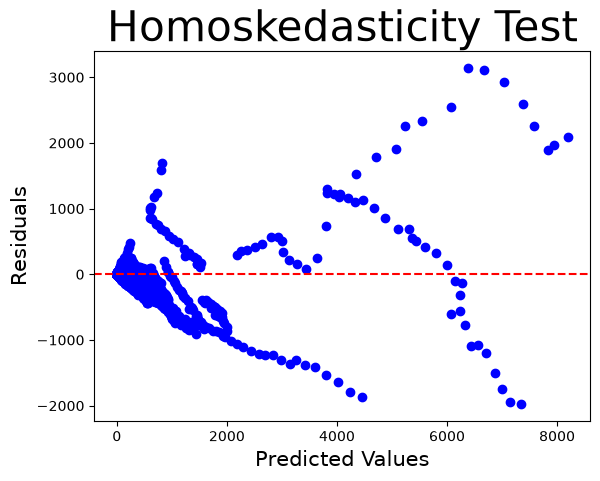

In [26]:
fittedvals_pooled_OLS = pooled_res.predict().fitted_values
residuals_pooled_OLS  = pooled_res.resids

fig, ax = plt.subplots()
ax.scatter(fittedvals_pooled_OLS, residuals_pooled_OLS, color = 'blue')
ax.axhline(0, color = 'r', ls = '--')
ax.set_xlabel('Predicted Values', fontsize = 15)
ax.set_ylabel('Residuals', fontsize = 15)
ax.set_title('Homoskedasticity Test', fontsize = 30)
plt.show()

## White-Test

In [29]:
pooled_OLS_dataset = pd.concat([data, residuals_pooled_OLS], axis=1)
white_test_results = het_white(pooled_OLS_dataset['residual'], exog)
labels = ['LM-Stat', 'LM p-val', 'F-Stat', 'F p-val'] 
print(dict(zip(labels, white_test_results)))

AssertionError: 

## Breusch-Pagan-Test

In [28]:
breusch_pagan_test_results = het_breuschpagan(pooled_OLS_dataset['residual'], exog)
print(dict(zip(labels, breusch_pagan_test_results)))

NameError: name 'labels' is not defined

## In simple terms, if p < 0.05, then heteroskedasticity is indicated. Both tests give very small p-values. Hence, we have heteroskedasticity

# now check autocorrelation
## Durbin-Watson-Test

In [20]:
durbin_watson_test_results = durbin_watson(pooled_OLS_dataset['residual']) 
print(durbin_watson_test_results)

0.5012862296798662


## The Durbin-Watson-Test will have one output between $0$ and $4$. The mean $(= 2)$ would indicate that there is no autocorrelation identified, $0$ to $2$ means positive autocorrelation (the nearer to zero the higher the correlation), and $2$ to $4$ means negative autocorrelation (the nearer to four the higher the correlation). In our example, the result is $0.5$, which clearly indicates strong positive autocorrelation.

# hence, we need robust se, even though it does not bring too much change

---

# Random effect

In [31]:
mod_re = RandomEffects(data.co2, exog, check_rank = False)
re_res = mod_re.fit()
print(re_res)

                        RandomEffects Estimation Summary                        
Dep. Variable:                    co2   R-squared:                        0.7215
Estimator:              RandomEffects   R-squared (Between):              0.9194
No. Observations:                4698   R-squared (Within):               0.6921
Date:                Tue, Jun 16 2026   R-squared (Overall):              0.8943
Time:                        19:45:18   Log-likelihood                -2.965e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      4052.7
Entities:                         162   P-value                           0.0000
Avg Obs:                       29.000   Distribution:                  F(3,4694)
Min Obs:                       29.000                                           
Max Obs:                       29.000   F-statistic (robust):             4039.6
                            

In [24]:
re_res_rb = mod_re.fit(cov_type='robust')
print(re_res_rb)

                        RandomEffects Estimation Summary                        
Dep. Variable:                  lfare   R-squared:                        0.2285
Estimator:              RandomEffects   R-squared (Between):              0.4175
No. Observations:                4596   R-squared (Within):               0.1348
Date:                Thu, Oct 07 2021   R-squared (Overall):              0.4029
Time:                        07:59:39   Log-likelihood                    3771.5
Cov. Estimator:                Robust                                           
                                        F-statistic:                      226.57
Entities:                        1149   P-value                           0.0000
Avg Obs:                       4.0000   Distribution:                  F(6,4589)
Min Obs:                       4.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             210.08
                            

# now, we can decompose the total variance of Y into 2 parts

* the variance of Y explained by the effects
* the variance of Y that cannot be expalined

In [25]:
print("the total variance of Y is ", np.var(data.lfare))

the total variance of Y is  0.19040347706674826


In [26]:
re_res.variance_decomposition

Effects                   0.102251
Residual                  0.011351
Percent due to Effects    0.900078
Name: Variance Decomposition, dtype: float64

## The coefficient $\theta_i$ determines how much demeaning takes place. When this value is 1, the RE model reduces to the pooled model since this occurs when there is no variance in the effects. When panels are unbalanced it will vary across entities, but in this balanced panel all values are the same.

In [27]:
re_res.theta.head()

,theta
id,
1,0.83567
2,0.83567
3,0.83567
4,0.83567
5,0.83567


# Now, let's do fixed effect

In [33]:
#exog_vars = ['y98','y99','y00','concen']
exog = sm.add_constant(data[exog_vars])
mod_fe = PanelOLS(data.co2, exog, entity_effects=True)
fe_res = mod_fe.fit()
print(fe_res)

AbsorbingEffectError: 
The model cannot be estimated. The included effects have fully absorbed
one or more of the variables. This occurs when one or more of the dependent
variable is perfectly explained using the effects included in the model.

The following variables or variable combinations have been fully absorbed
or have become perfectly collinear after effects are removed:

          const, population, gdp, Carbon_price_DV
          const, population, gdp, Carbon_price_DV

Set drop_absorbed=True to automatically drop absorbed variables.


In [29]:
fe_res_rb = mod_fe.fit(cov_type='robust')
print(fe_res_rb)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  lfare   R-squared:                        0.1352
Estimator:                   PanelOLS   R-squared (Between):             -0.0417
No. Observations:                4596   R-squared (Within):               0.1352
Date:                Thu, Oct 07 2021   R-squared (Overall):             -0.0325
Time:                        08:00:19   Log-likelihood                    4435.1
Cov. Estimator:                Robust                                           
                                        F-statistic:                      134.61
Entities:                        1149   P-value                           0.0000
Avg Obs:                       4.0000   Distribution:                  F(4,3443)
Min Obs:                       4.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             120.79
                            

In [31]:
print(compare({"FE": fe_res, 
               "FE_rb": fe_res_rb, 
               "RE": re_res, "RE_rb": 
               re_res_rb, 
               "Pooled": pooled_res, 
               "Pooled_rb": pooled_robust_res}))

                                                  Model Comparison                                                  
                                    FE        FE_rb                RE             RE_rb         Pooled     Pooled_rb
--------------------------------------------------------------------------------------------------------------------
Dep. Variable                    lfare        lfare             lfare             lfare          lfare         lfare
Estimator                     PanelOLS     PanelOLS     RandomEffects     RandomEffects      PooledOLS     PooledOLS
No. Observations                  4596         4596              4596              4596           4596          4596
Cov. Est.                   Unadjusted       Robust        Unadjusted            Robust     Unadjusted        Robust
R-squared                       0.1352       0.1352            0.2285            0.2285         0.4062        0.4062
R-Squared (Within)              0.1352       0.1352            0

# Hausman test : there is no Hausman test in Python, so I coded it myself.

In [32]:
b = fe_res.params[1:]
print(b)
B = re_res.params[1:5]
print(B)

y98       0.022833
y99       0.036382
y00       0.097772
concen    0.168859
Name: parameter, dtype: float64
y98       0.022475
y99       0.036689
y00       0.098211
concen    0.208927
Name: parameter, dtype: float64


In [33]:
v_b = fe_res.cov.drop('const', axis=1)
v_b = v_b[1:]
print(v_b)
v_B = re_res.cov.drop(['const','ldist','ldistsq'], axis=1)
v_B = v_B[1:5]
print(v_B)

             y98       y99       y00    concen
y98     0.000020  0.000010  0.000010 -0.000008
y99     0.000010  0.000020  0.000010  0.000007
y00     0.000010  0.000010  0.000020  0.000009
concen -0.000008  0.000007  0.000009  0.000865
             y98       y99       y00    concen
y98     0.000020  0.000010  0.000010 -0.000006
y99     0.000010  0.000020  0.000010  0.000005
y00     0.000010  0.000010  0.000020  0.000008
concen -0.000006  0.000005  0.000008  0.000704


In [34]:
df = b[np.abs(b) < 1e8].size
chi2 = np.dot((b-B).T, la.inv(v_b - v_B).dot(b - B)) 
pval = stats.chi2.sf(chi2, df)


dict = {'chi-sq stat' : [chi2],
        'df' : [df],
        'p-value' : [pval]}
Hausman_df = pd.DataFrame(dict)

In [35]:
Hausman_df.round(2)

,chi-sq stat,df,p-value
0,9.96,4,0.04


In [36]:
!rm -rf W7_Python.html
!jupyter nbconvert --to html W7_Python.ipynb

[NbConvertApp] Converting notebook W7_Python.ipynb to html
[NbConvertApp] Writing 666532 bytes to W7_Python.html
